# Family B screener — set a date, run all, get the trade

The working instrument for the two surviving structures of the dispersion
program. Set `date` below to a session or to `"live"`, run the notebook, and
read the ticket at the bottom.

* **carry sleeve** — short the modal 25bp butterfly on the front quarterly,
  rolled at expiry−3d. Always on, so there is no entry signal to wait for:
  what matters is the position and the roll clock.
* **fade sleeve** — sell (buy) the ±75bp strangle on the front quarterly when
  its listed premium sits `thr` bp above (below) the ZQ-lattice fair value,
  exit at 25% of entry richness or 15 sessions, never held to expiry. This is
  the one with a trigger, and the reason to look at this notebook daily.

Everything routes through `famb_screener`, which routes through `famb_common`
— the same strike selection, marks and fair value the backtest used. Nothing
here recomputes the signal a second way.

In [1]:
CONFIG = dict(
    date="live",            # "live", or a session e.g. "2026-08-03"
    history=250,            # sessions of context behind the screen date
    lots=100,               # position size for the $ figures
    dollars_per_bp=25.0,    # per contract-lot
    books=("STRG75", "STRG50", "FLY25", "FLY50", "DFLY"),
    ranks=(1, 2, 3),
    thr_bp=4.0,             # entry threshold (pre-registered value)
    exit_frac=0.25,         # exit at this fraction of entry richness
    max_hold=15,            # sessions
    direction="fade",       # fade | momentum
    cost_mult=1.0,          # half-tick multiplier
    refresh=None,           # None = auto (live implies a settle refresh)
    intraday=False,         # True marks live instead of on settles (uncalibrated)
    self_check=True,        # re-run a known-good date at the end
)
CONFIG

{'date': 'live',
 'history': 250,
 'lots': 100,
 'dollars_per_bp': 25.0,
 'books': ('STRG75', 'STRG50', 'FLY25', 'FLY50', 'DFLY'),
 'ranks': (1, 2, 3),
 'thr_bp': 4.0,
 'exit_frac': 0.25,
 'max_hold': 15,
 'direction': 'fade',
 'cost_mult': 1.0,
 'refresh': None,
 'intraday': False,
 'self_check': True}

In [2]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

import famb_screener as scr                                  # noqa: E402

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
DPB = CONFIG["lots"] * CONFIG["dollars_per_bp"]

ctx = scr.load_context(CONFIG["date"], history=CONFIG["history"],
                       refresh=CONFIG["refresh"], ranks=CONFIG["ranks"],
                       books=CONFIG["books"], intraday=CONFIG["intraday"])
ideas = scr.screen(ctx, books=CONFIG["books"], ranks=CONFIG["ranks"],
                   thr_bp=CONFIG["thr_bp"], exit_frac=CONFIG["exit_frac"],
                   max_hold=CONFIG["max_hold"], direction=CONFIG["direction"],
                   cost_mult=CONFIG["cost_mult"])
carry = scr.carry_state(ctx, cost_mult=CONFIG["cost_mult"])
print(f"screened {ctx.as_of.date()}  "
      f"({'live' if ctx.live else 'historical'}"
      f"{', quotes fetched' if ctx.fetched else ''})   "
      f"{len(ideas)} cells   history {ctx.dates[0].date()} -> "
      f"{ctx.dates[-1].date()}")

C:\Users\chris\clee\ARBS-xm\MDP\IRSwaps\SDR_INTRADAY\rl_curve_utils\tos.py:14: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


screened 2026-08-05  (live, quotes fetched)   15 cells   history 2025-08-21 -> 2026-08-05


## The screen

In [3]:
print(scr.format_report(ctx, ideas, carry, lots=CONFIG["lots"],
                        dollars_per_bp=CONFIG["dollars_per_bp"]))

FAMILY B SCREENER  |  LIVE as of 2026-08-05  (quotes fetched this run)
  screen date 2026-08-05   history 2025-08-21 -> 2026-08-05 (250 sessions)
  settles current to 2026-08-05

-- SLEEVE 1: carry (always on) -----------------------------------------------------------------
  SHORT FLY25 SFRU26 96.00/96.25/96.50   held since 2026-06-09
  mark 13.50bp   fair 12.24bp   richness +1.26bp
  expiry 2026-09-11   ROLL ON 2026-09-08 (34 calendar days)   roll cost 1.00bp

-- SLEEVE 2: richness fade (signal-gated) -----------------------------------------------------
  cell        sym      dte    rich   level     dev     z  net@1x xcost  risk  state
  ---------------------------------------------------------------------------------
 *STRG75 Q1   SFRU26    37   +0.50   +1.25   -0.75  -1.4   -0.13  +0.7   UNB  WATCH (needs +3.50bp more rich)
  FLY50 Q1    SFRU26    37   +1.28   -0.53   +1.81  +1.4   +0.35  +1.4   def  WATCH (needs +2.19bp more dev)
  FLY25 Q1    SFRU26    37   +1.26   +0.68   +0.5

## The cross-section, drawn

`dev` is richness minus the cell's **own contract's** standing level — the
comparable number. Raw richness is not comparable across ranks: the
off-lattice premium grows with days to expiry, so a back contract sits
permanently rich and a raw threshold there would fire every day.

The pre-registered cell is the exception and is drawn on its own scale: it is
gated on RAW richness, exactly as the backtest gates it.

     cell symbol  dte  rich_bp  level_bp  dev_bp     z  net_bp  x_cost  defined_risk  prereg state
STRG75 Q1 SFRU26   37     0.50      1.25   -0.75 -1.35   -0.13    0.75         False    True WATCH
 FLY50 Q1 SFRU26   37     1.28     -0.53    1.81  1.36    0.35    1.35          True   False WATCH
 FLY25 Q1 SFRU26   37     1.26      0.68    0.58  0.68   -0.57    0.43          True   False WATCH
 FLY50 Q2 SFRZ26  128    -3.37     -3.20   -0.17 -0.06   -0.87    0.13          True   False WATCH
  DFLY Q1 SFRU26   37     1.83      0.33    1.50  1.45   -0.87    0.56          True   False WATCH
 FLY25 Q3 SFRH27  219    -0.51     -0.36   -0.14 -0.12   -0.89    0.11          True   False WATCH
 FLY50 Q3 SFRH27  219    -4.32     -4.43    0.11  0.04   -0.92    0.08          True   False WATCH
 FLY25 Q2 SFRZ26  128     0.07      0.16   -0.09 -0.07   -0.93    0.07          True   False WATCH
  DFLY Q3 SFRH27  219    -1.83     -1.59   -0.25 -0.20   -1.81    0.09          True   False WATCH
  DFLY Q2 

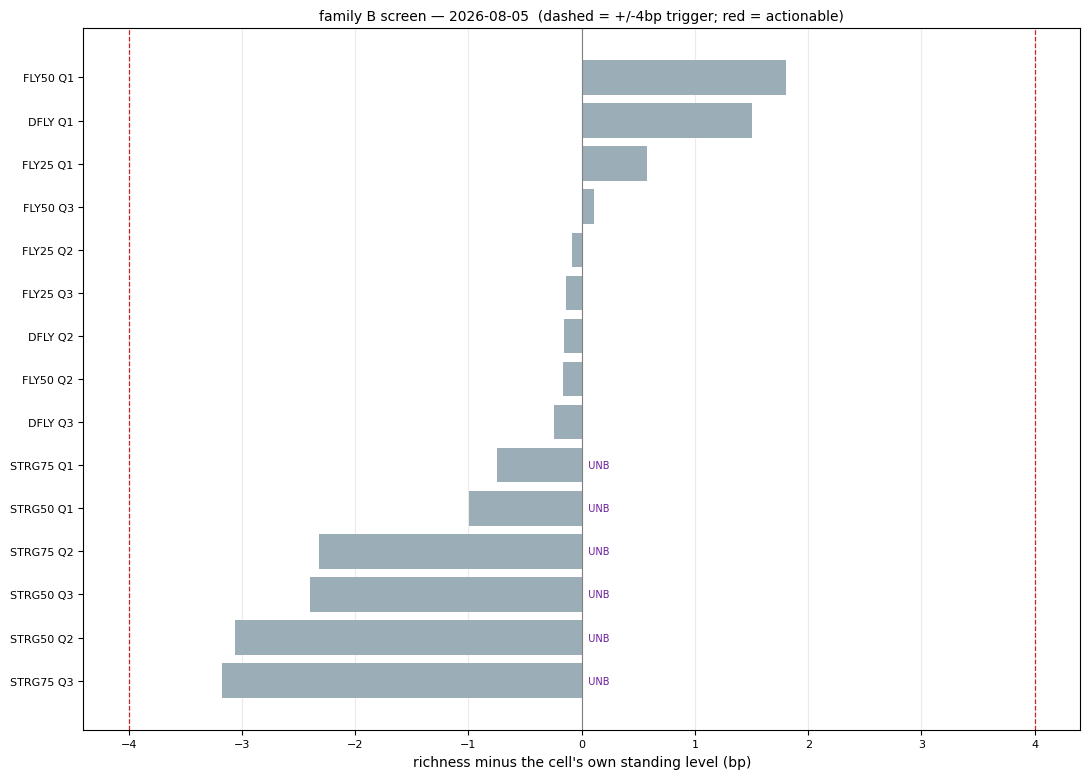

In [4]:
tab = pd.DataFrame([{
    "cell": f"{i.book} Q{i.rank}", "symbol": i.symbol, "dte": i.dte,
    "rich_bp": i.rich_bp, "level_bp": i.level_bp, "dev_bp": i.dev_bp,
    "z": i.z_dev, "net_bp": i.net_target_bp, "x_cost": i.edge_mult,
    "defined_risk": i.defined_risk, "prereg": i.prereg, "state": i.state,
} for i in ideas])
live_rows = tab[tab["state"].isin(["ACTIONABLE", "WATCH"])].copy()
print(tab.round(2).to_string(index=False))

if len(live_rows):
    d = live_rows.sort_values("dev_bp")
    colour = ["#c62828" if s == "ACTIONABLE" else "#90a4ae"
              for s in d["state"]]
    fig, ax = plt.subplots(figsize=(11, 0.42 * len(d) + 1.6))
    ax.barh(d["cell"], d["dev_bp"], color=colour, alpha=0.9)
    ax.axvline(0, color="grey", lw=0.8)
    for x in (-CONFIG["thr_bp"], CONFIG["thr_bp"]):
        ax.axvline(x, color="#c62828", lw=0.9, ls="--")
    ax.set_xlabel("richness minus the cell's own standing level (bp)")
    ax.set_title(f"family B screen — {ctx.as_of.date()}  "
                 f"(dashed = +/-{CONFIG['thr_bp']:.0f}bp trigger; "
                 f"red = actionable)", fontsize=10)
    for y, (_, r) in enumerate(d.iterrows()):
        if not r["defined_risk"]:
            ax.text(0, y, "  UNB", va="center", ha="left", fontsize=7,
                    color="#6a1b9a")
    ax.grid(alpha=0.25, axis="x")
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

## The pre-registered cell, in context

The only cell with a mandate. Its gate is `|richness| >= thr` on the RAW
number, so the trigger bands are drawn around zero; the dashed line is the
contract's own standing level, shown for reference rather than as a gate.

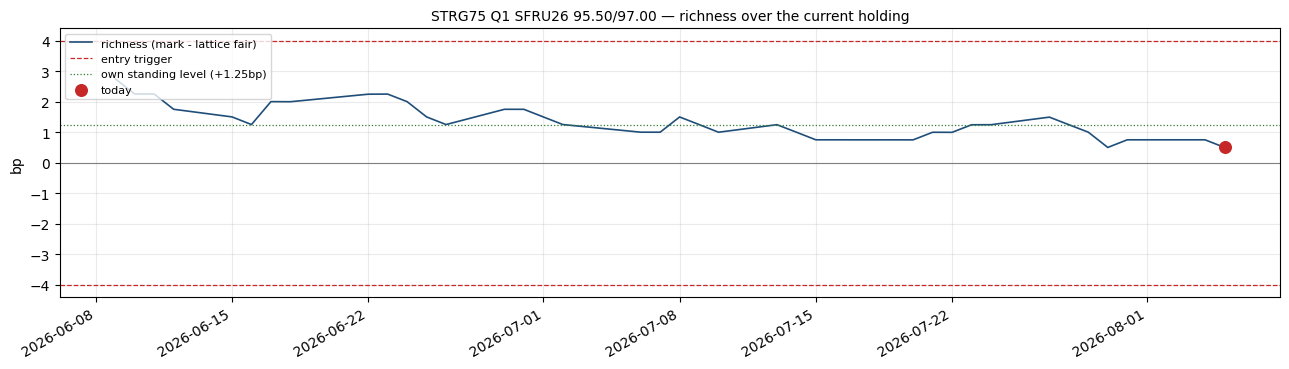

            mark_bp  fair_bp  rich_bp
2026-07-23     1.25     0.01     1.24
2026-07-24     1.25     0.01     1.24
2026-07-27     1.50     0.01     1.49
2026-07-28     1.25     0.01     1.24
2026-07-29     1.00     0.00     1.00
2026-07-30     0.50     0.00     0.50
2026-07-31     0.75     0.00     0.75
2026-08-03     0.75     0.00     0.75
2026-08-04     0.75     0.00     0.75
2026-08-05     0.50     0.00     0.50


In [5]:
pr = scr.PREREG
out = scr.richness_series(ctx, pr["book"], pr["rank"])
if out is None:
    print(f"{pr['book']} Q{pr['rank']}: no book on this date")
else:
    hist, hold = out
    idea = next((i for i in ideas
                 if i.book == pr["book"] and i.rank == pr["rank"]), None)
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.plot(hist.index, hist["rich_bp"], lw=1.2, color="#1f4e79",
            label="richness (mark - lattice fair)")
    ax.axhline(0, color="grey", lw=0.8)
    for s in (+1, -1):
        ax.axhline(s * CONFIG["thr_bp"], color="#c62828", lw=0.9, ls="--",
                   label="entry trigger" if s > 0 else None)
    if idea is not None and np.isfinite(idea.level_bp):
        ax.axhline(idea.level_bp, color="#2e7d32", lw=0.9, ls=":",
                   label=f"own standing level ({idea.level_bp:+.2f}bp)")
    ax.scatter([hist.index[-1]], [hist["rich_bp"].iloc[-1]], s=70,
               color="#c62828", zorder=5, label="today")
    ax.set_title(f"{pr['book']} Q{pr['rank']} {hold.symbol} "
                 f"{'/'.join(f'{k:.2f}' for _, k, _ in hold.legs)} — "
                 f"richness over the current holding", fontsize=10)
    ax.set_ylabel("bp")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    print(hist.tail(10).round(2).to_string())

## The carry sleeve

No signal to wait for — this one is always on. What matters is the mark
against fair (is the position carrying well) and the roll clock.

SHORT FLY25 SFRU26 96.00/96.25/96.50   held since 2026-06-09
roll on 2026-09-08 — 34 calendar days (24 sessions), roll cost 1.00bp ($2,500)


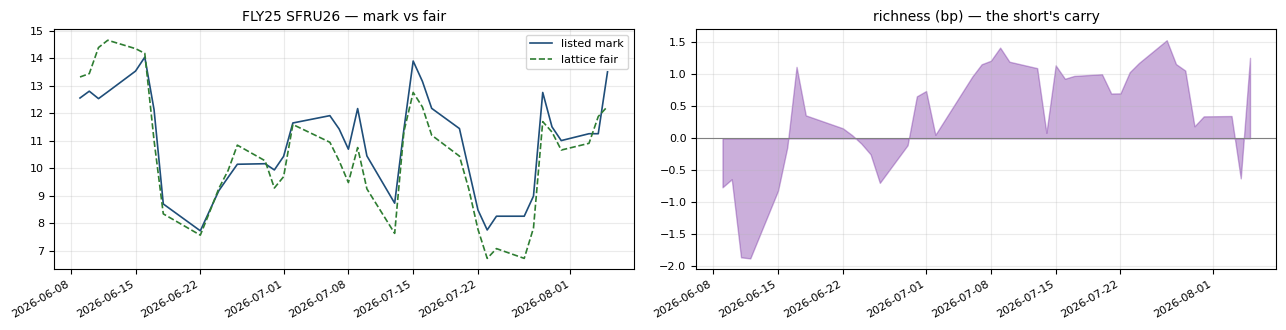

In [6]:
if carry is None:
    print("no carry book could be built")
else:
    print(f"{carry['side'].upper()} {carry['book']} {carry['symbol']} "
          f"{'/'.join(f'{k:.2f}' for _, k, _ in carry['legs'])}   "
          f"held since {carry['held_since']}")
    print(f"roll on {carry['roll_on']} — {carry['days_to_roll']} calendar days "
          f"({carry['sessions_to_roll']} sessions), roll cost "
          f"{carry['roll_cost_bp']:.2f}bp "
          f"(${carry['roll_cost_bp'] * DPB:,.0f})")
    cout = scr.richness_series(ctx, carry["book"], carry["rank"])
    if cout is not None:
        chist, _ = cout
        fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
        axes[0].plot(chist.index, chist["mark_bp"], lw=1.2, color="#1f4e79",
                     label="listed mark")
        axes[0].plot(chist.index, chist["fair_bp"], lw=1.2, color="#2e7d32",
                     ls="--", label="lattice fair")
        axes[0].set_title(f"{carry['book']} {carry['symbol']} — mark vs fair",
                          fontsize=10)
        axes[0].legend(fontsize=8)
        axes[1].fill_between(chist.index, chist["rich_bp"], 0,
                             color="#6a1b9a", alpha=0.35)
        axes[1].axhline(0, color="grey", lw=0.8)
        axes[1].set_title("richness (bp) — the short's carry", fontsize=10)
        for a in axes:
            a.grid(alpha=0.25)
            a.tick_params(labelsize=8)
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

## The ticket

Legs as they would be sent. Empty when nothing triggers, which is the normal
state — and distinguishable from the screener having no data, which shouts.

In [7]:
act = [i for i in ideas if i.state == "ACTIONABLE"]
if not act:
    print("no ticket — nothing triggered")
    near = scr.closest_to_trigger(ideas)      # same helper the report uses
    if near is not None:
        print(f"nearest of any cell: {near.book} Q{near.rank} — "
              f"{near.gate_note} ({scr.gap_to_trigger(near):+.2f}bp away)")
else:
    prereg_hits = [i for i in act if i.prereg]
    pick = prereg_hits[0] if prereg_hits else act[0]
    print(f"{'PRE-REGISTERED' if pick.prereg else 'EXPLORATORY (no mandate)'}"
          f"   {'SELL' if pick.side < 0 else 'BUY'} {pick.book} "
          f"{pick.symbol}")
    print(pd.DataFrame(pick.ticket(CONFIG["lots"])).to_string(index=False))
    print(f"\nexpected net {pick.net_target_bp:+.2f}bp "
          f"(${pick.net_target_bp * DPB:+,.0f}) at "
          f"{pick.edge_mult:.1f}x the round trip; exit at richness "
          f"{pick.exit_rich_bp:+.2f}bp or {pick.max_hold_date}")
    if not pick.defined_risk and pick.side < 0:
        print("RISK: short strangle — worst case unbounded; the time stop is "
              "part of the strategy")

no ticket — nothing triggered
nearest of any cell: STRG75 Q3 — needs +0.82bp more dev (+0.82bp away)


In [8]:
recs = scr.to_records(ideas)
print(f"{len(recs)} machine-readable records "
      f"(same shape as `famb_screener.py --json`); first actionable or best:")
best = next((r for r in recs if r["state"] == "ACTIONABLE"), recs[0])
for k in ("book", "rank", "symbol", "state", "action", "rich_bp", "level_bp",
          "dev_bp", "z_dev", "level_source", "net_target_bp", "exit_rich_bp",
          "max_hold_date", "defined_risk", "prereg"):
    v = best[k]
    print(f"  {k:16s} {round(v, 4) if isinstance(v, float) else v}")

15 machine-readable records (same shape as `famb_screener.py --json`); first actionable or best:
  book             STRG75
  rank             1
  symbol           SFRU26
  state            WATCH
  action           -
  rich_bp          0.5
  level_bp         1.2471
  dev_bp           -0.7471
  z_dev            -1.35
  level_source     own
  net_target_bp    -0.125
  exit_rich_bp     0.125
  max_hold_date    2026-08-26
  defined_risk     False
  prereg           True


## Self-check

2023-03-20 is the post-SVB richness spike the findings doc records as the
fade's best entry (+44bp collected as the panic premium converged). If the
notebook is wired to the same signal it must fire there, whatever today says.

In [9]:
if CONFIG["self_check"]:
    ctx_x = scr.load_context("2023-03-20", history=CONFIG["history"])
    ideas_x = scr.screen(ctx_x, books=(scr.PREREG["book"],), ranks=(1,),
                         thr_bp=CONFIG["thr_bp"])
    i_x = ideas_x[0]
    print(f"2023-03-20  {i_x.book} Q{i_x.rank} {i_x.symbol}: "
          f"richness {i_x.rich_bp:+.2f}bp -> {i_x.state} "
          f"({'SELL' if i_x.side < 0 else 'BUY'})")
    assert i_x.state == "ACTIONABLE" and i_x.side < 0, \
        "the known post-SVB entry no longer fires — the signal has drifted"
    print("OK — the known entry still fires, and still on the sell side")
else:
    print("self-check skipped")

2023-03-20  STRG75 Q1 SFRM23: richness +28.73bp -> ACTIONABLE (SELL)
OK — the known entry still fires, and still on the sell side


## Read this before acting

The fade's parameters won a 720-config search: **DSR 0.000, house verdict
SELECTION-ARTIFACT**. Its mechanism is measured — 7–18 session richness
half-lives, frontier-consistent levels by rank, positive skew through SVB —
but the exact numbers are selection-inflated, and the carry short's NW t is
1.51, real-looking and not significant. Running the pre-registered cell
unchanged, forward, is the one-trial test that discharges the penalty.

Every cell other than the starred one is an exploratory read with no mandate.
They are gated harder for it — deviation from the contract's own level plus a
sigma floor — because a raw threshold on a back contract is a standing short
of the off-lattice premium, which is the trade the referee's ruling killed
(worst days −55/−92bp, skew −7.15).

The screener enters lag-1, so a ticket printed here is for the **next**
session; the backtest's numbers assume that lag.